# Weekly Project 06 - 3D Point Cloud Processing 2

Today we will continue the work from Monday.
We will follow the style of last week.

Weekly project:

- You will need to implement your own k-means algorithm. You are not allowed to use the implementation in `sklearn`.
- It should be able to cluster each of the different figures.
- Extend your k-means algorithm so that it finds the optimal number of clusters.

## Challenge

- Implement the mean shift clustering algorithm.


## Weekly Project 06 - Start Here

In [75]:
import numpy as np
import open3d as o3d
import copy
import matplotlib.pyplot as plt

def draw_labels_on_model(pcl, labels):
    cmap = plt.get_cmap("tab20")
    pcl_temp = copy.deepcopy(pcl)
    max_label = labels.max()
    colors = cmap(labels / (max_label if max_label > 0 else 1))
    colors[labels < 0] = 0
    pcl_temp.colors = o3d.utility.Vector3dVector(colors[:, :3])
    o3d.visualization.draw_geometries([pcl_temp])

d = 4
mesh = o3d.geometry.TriangleMesh.create_tetrahedron().translate((-d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_octahedron().translate((0, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_icosahedron().translate((d, 0, 0))
mesh += o3d.geometry.TriangleMesh.create_torus().translate((-d, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=1).translate((0, -d, 0))
mesh += o3d.geometry.TriangleMesh.create_mobius(twists=2).translate((d, -d, 0))

point_cloud = mesh.sample_points_uniformly(int(1e3))


### K-means Algorithm

This cell defines k-means using one random initialisation. It places k centres uniformly inside the bounding box of the point cloud, assigns each point to its nearest centre, and moves each non-empty centre to the mean of its assigned points. It repeats these steps until the centres change very little or the iteration limit is reached.

`dists` stores the Euclidean distance from every point to every centre. Its shape is `(N, k)`, where `N` is the number of points and `k` is the number of centres. Each row contains one point's distances to all centres, so `dists[i, j]` is the distance from point `i` to centre `j`. `np.argmin(dists, axis=1)` then finds the nearest centre for each point.

The function returns one cluster label per point.

In [76]:
def kmeans(points, k, n_iter=200, seed=0):

    rng = np.random.default_rng(seed)  
    centers = rng.uniform(points.min(axis=0), points.max(axis=0), size=(k, points.shape[1]))

    for _ in range(n_iter):
        dists = np.linalg.norm(points[:, None, :] - centers[None, :, :], axis=2)
        labels = np.argmin(dists, axis=1)
        new_centers = np.array([points[labels == q].mean(axis=0) if np.any(labels == q) else centers[q] for q in range(k)])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    return labels


This cell converts the point cloud to a NumPy array, calls k-means with k = 6, and displays the result with a colour for each cluster. We choose six clusters to match the six geometric shapes used to generate the point cloud, aiming to assign one cluster to each shape. The shapes are arranged in two rows, with a spacing of d=4.

In [77]:
# Convert the point cloud to a NumPy array with one (x, y, z) row per point.
xyz = np.asarray(point_cloud.points)
k = 6
labels = kmeans(xyz, k)
draw_labels_on_model(point_cloud, labels)


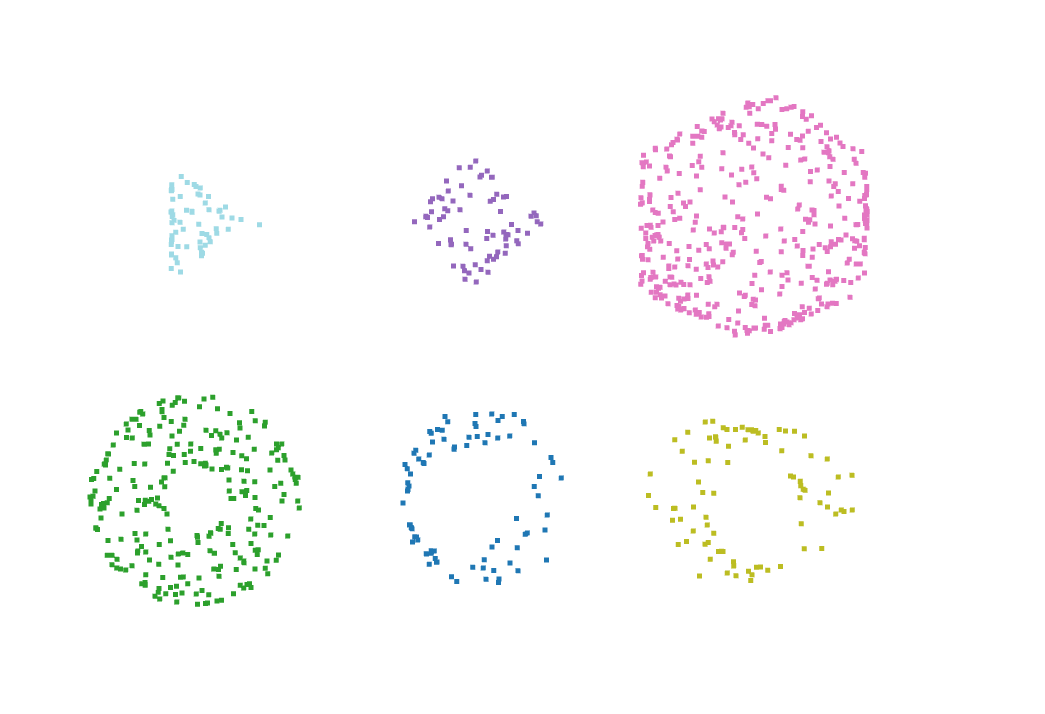

### Extended k-means algorithm for optimal number of clusters.


This cell tries k values from 1 to 10 on the same point cloud. For each result, it calculates distortion as the sum of squared distances from points to their cluster means. It estimates the elbow using the largest distance above the line joining the normalised curve endpoints, then plots the curve and displays the chosen clustering.

The saved output shows k = 2, even though the scene contains six figures. This elbow estimate is a heuristic and depends on the sampled points, the initial centres and the tested range. Empty clusters can also make the number of occupied clusters smaller than the requested k.

Elbow estimate: k = 2


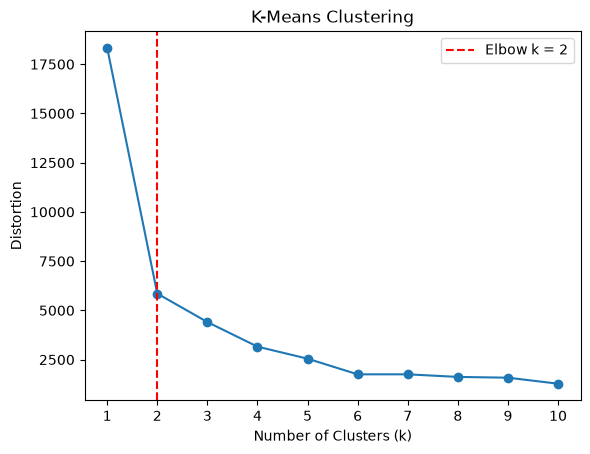

In [78]:
# Use the same point cloud as in the fixed-k example above.
k_values = range(1, 11)
distortions = []
labels_by_k = []

for k in k_values:
    labels = kmeans(xyz, k)
    labels_by_k.append(labels)

    # Distortion is the sum of squared distances to each cluster's mean.
    distortion = 0
    for label in np.unique(labels):
        cluster_points = xyz[labels == label]
        center = cluster_points.mean(axis=0)
        distortion += np.sum((cluster_points - center) ** 2)
    distortions.append(distortion)

# Normalise the curve and find the point furthest above its endpoint line.
if distortions[0] == distortions[-1]:
    best_index = 0
else:
    x = np.linspace(0, 1, len(k_values))
    y = (distortions[0] - np.array(distortions)) / (distortions[0] - distortions[-1])
    best_index = int(np.argmax(y - x))
best_k = k_values[best_index]
labels = labels_by_k[best_index]
print(f"Elbow estimate: k = {best_k}")

plt.figure()
plt.plot(k_values, distortions, marker="o")
plt.axvline(best_k, color="red", linestyle="--", label=f"Elbow k = {best_k}")
plt.xticks(k_values)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Distortion")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

draw_labels_on_model(point_cloud, labels)


![kmeans algo2.png](<attachment:kmeans algo2.png>)
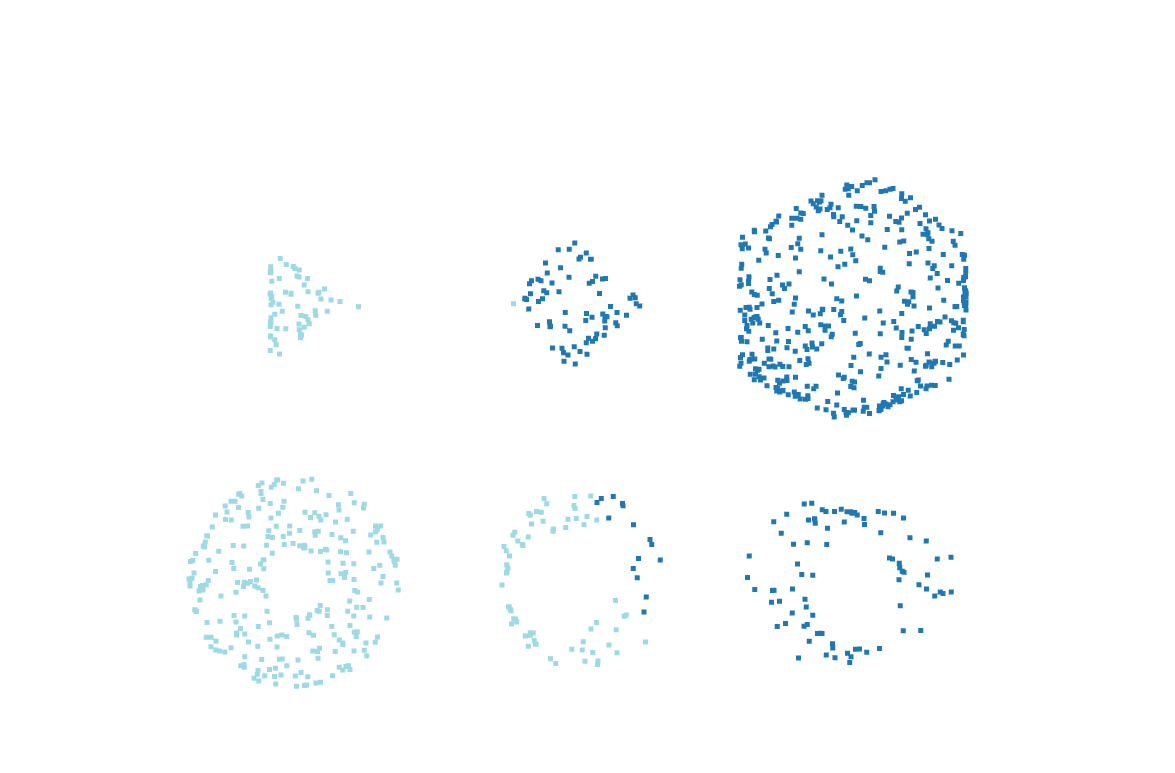

In [ ]:
def mean_shift(points, bandwidth, max_iter=100, tol=1e-3,
               merge_distance=None, batch_size=256):
    X = np.asarray(points, dtype=float)

    if merge_distance is None:
        merge_distance = bandwidth / 2

    # Start one moving point at each input point.
    modes = X.copy()
    n_points = len(X)

    for _ in range(max_iter):
        updated_modes = np.empty_like(modes)

        # Process in batches to limit memory use.
        for start in range(0, n_points, batch_size):
            stop = min(start + batch_size, n_points)
            current = modes[start:stop]

            # Distance from these moving points to every input point.
            delta = current[:, None, :] - X[None, :, :]
            distances_sq = np.sum(delta ** 2, axis=2)

            # Gaussian kernel: closer points have more influence.
            weights = np.exp(
                -distances_sq / (2 * bandwidth ** 2)
            )

            # Move each point to its weighted mean.
            updated_modes[start:stop] = (
                weights @ X
            ) / weights.sum(axis=1, keepdims=True)

        movement = np.linalg.norm(updated_modes - modes, axis=1).max()
        modes = updated_modes

        if movement <= tol:
            break

    # Merge points whose final modes are close together.
    labels = np.full(n_points, -1, dtype=int)
    centers = []
    counts = []

    for i, mode in enumerate(modes):
        if centers:
            distances = np.linalg.norm(np.asarray(centers) - mode, axis=1)
            nearest = np.argmin(distances)

            if distances[nearest] <= merge_distance:
                labels[i] = nearest
                counts[nearest] += 1
                centers[nearest] += (mode - centers[nearest]) / counts[nearest]
                continue

        labels[i] = len(centers)
        centers.append(mode.copy())
        counts.append(1)

    return labels, np.asarray(centers)

In [ ]:
def estimate_bandwidth(points, k=20, sample_size=2000, multiplier=1.5):
    """Estimate bandwidth from the local spacing of the point cloud."""
    points = np.asarray(points, dtype=float)
    if points.ndim != 2 or len(points) < 2:
        raise ValueError("points must have shape (N, D) with N >= 2")

    if len(points) > sample_size:
        rng = np.random.default_rng(42)
        sample = points[rng.choice(len(points), sample_size, replace=False)]
    else:
        sample = points

    k = min(k, len(sample) - 1)
    differences = sample[:, None, :] - sample[None, :, :]
    distances = np.linalg.norm(differences, axis=2)
    np.fill_diagonal(distances, np.inf)
    kth_distances = np.partition(distances, k - 1, axis=1)[:, k - 1]

    bandwidth = multiplier * np.median(kth_distances)
    if not np.isfinite(bandwidth) or bandwidth <= 0:
        raise ValueError("Could not estimate a positive bandwidth")
    return float(bandwidth)


points = np.asarray(point_cloud.points)
automatic_bandwidth = estimate_bandwidth(points)
labels, centers = mean_shift(
    points,
    bandwidth=automatic_bandwidth,
    merge_distance=automatic_bandwidth / 2,
)

print(f"Automatic bandwidth: {automatic_bandwidth:.4f}")
print("Clusters found:", len(centers))
draw_labels_on_model(point_cloud, labels)

In [ ]:
points = np.asarray(point_cloud.points)
bandwidths = automatic_bandwidth * np.array([0.6, 0.8, 1.0, 1.2, 1.5])

results = {}
cluster_counts = []

for h in bandwidths:
    labels, centers = mean_shift(
        points,
        bandwidth=h,
        merge_distance=h / 2,
    )
    sizes = np.bincount(labels)

    results[h] = (labels, centers)
    cluster_counts.append(len(centers))

    print(
        f"bandwidth={h:.1f}: "
        f"{len(centers)} clusters; "
        f"cluster sizes={sizes.tolist()}"
    )
    

plt.plot(bandwidths, cluster_counts, marker="o")
plt.xlabel("Bandwidth")
plt.ylabel("Number of clusters")
plt.xticks(bandwidths)
plt.grid(True)
plt.show()

selected_bandwidth = bandwidths[np.argmin(np.abs(bandwidths - automatic_bandwidth))]
labels, centers = results[selected_bandwidth]
print(f"Selected bandwidth: {selected_bandwidth:.4f}")
draw_labels_on_model(point_cloud, labels)